Title:Design and implement a CNN for Image Classification a) Select a suitable image classification dataset (medical imaging, agricultural, etc.). b) Optimized with different hyper-paramet

In [ ]:
!pip install tensorflow-datasets

In [ ]:
!pip install importlib-resources

In [ ]:
pip install "pandas<3" "protobuf<7"

Start from here :

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(dataset, info) = tfds.load(
    "tf_flowers",
    split=['train[:80%]', 'train[80%:]'],   # ✅ correct split
    with_info=True,
    as_supervised=True
)
train_ds, val_ds = dataset
class_names = info.features['label'].names
print(class_names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


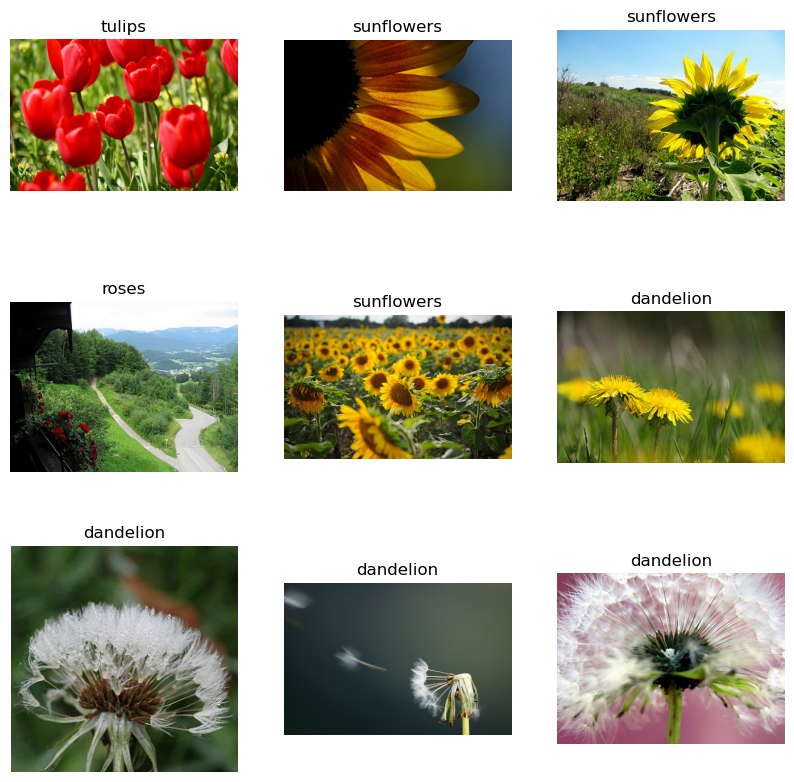

In [3]:
plt.figure(figsize=(10,10))

for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(image.numpy())
    plt.title(class_names[label.numpy()])
    plt.axis("off")

plt.show()

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 423ms/step - accuracy: 0.4009 - loss: 1.3931 - val_accuracy: 0.5150 - val_loss: 1.2048
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 416ms/step - accuracy: 0.5198 - loss: 1.1864 - val_accuracy: 0.6022 - val_loss: 1.0615
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 421ms/step - accuracy: 0.5569 - loss: 1.0961 - val_accuracy: 0.6253 - val_loss: 0.9660
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 454ms/step - accuracy: 0.5777 - loss: 1.0515 - val_accuracy: 0.6063 - val_loss: 0.9782
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 425ms/step - accuracy: 0.6025 - loss: 1.0105 - val_accuracy: 0.6376 - val_loss: 0.9117
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 429ms/step - accuracy: 0.6233 - loss: 0.9745 - val_accuracy: 0.6349 - val_loss: 0.9382
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 432ms/step - accuracy: 0.6257 - loss: 0.9695 - val_accuracy: 0.6376 - val_loss: 0.9118
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 457ms/step - accuracy: 0.6529 - loss: 0.9171 - val_accu

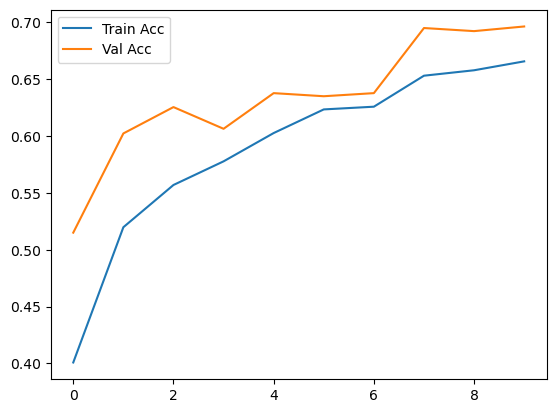

In [6]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


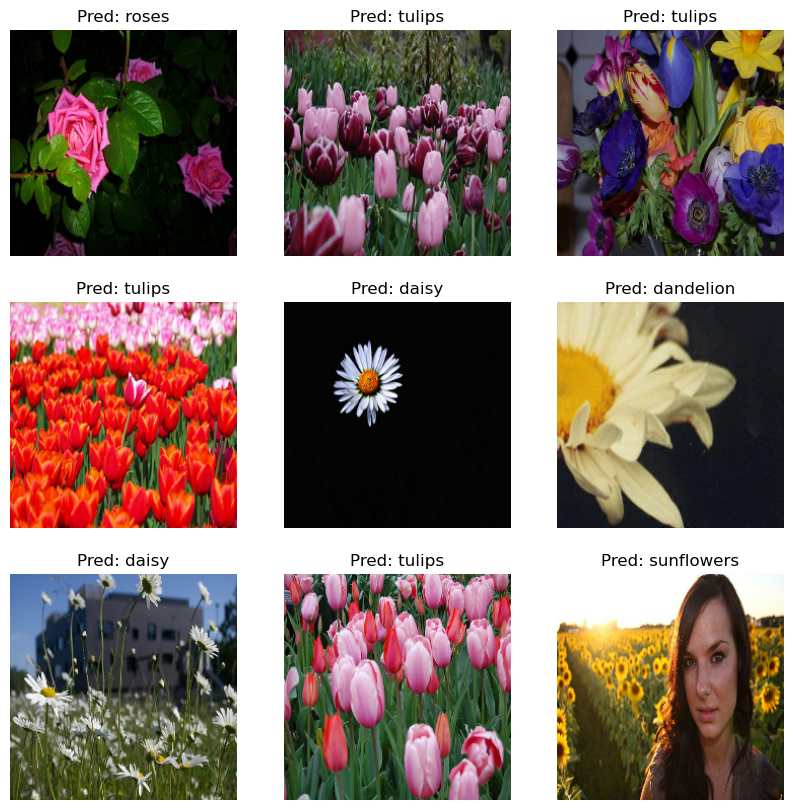

In [7]:
plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[pred_labels[i]]}")
        plt.axis("off")

plt.show()